# 04 · Baseline Regresión Logística
## Tesis UBA 2026 — LLMs vs. ML Clásico para Credit Scoring

Baseline **lineal e interpretable**, contrapunto de XGBoost. Entrenamos paso a paso usando
las funciones de `scripts/04_baseline_logreg.py` (encapsuladas en `train_logreg`).

### ¿Por qué incluirlo?
La Regresión Logística es el estándar histórico de la industria (Hand & Henley, 1997):
coeficientes interpretables como *log-odds*, fácil de auditar. Mide cuánto aporta la
no-linealidad de XGBoost sobre un modelo lineal bien regularizado.

### Diseño
Pipeline `imputación (mediana) → escalado estándar → LogReg L2 (C=0.1)`. La imputación y el
escalado se ajustan **solo sobre train** (dentro del `Pipeline`), evitando *leakage*. Mismo
split temporal que XGBoost; reportamos AUC train/val/test.

In [1]:
import importlib.util
from pathlib import Path

import pandas as pd
from IPython.display import Image


def _find_base() -> Path:
    base = Path.cwd()
    while not (base / "scripts").exists() and base != base.parent:
        base = base.parent
    return base


BASE = _find_base()


def load_script(filename: str):
    path = BASE / "scripts" / filename
    spec = importlib.util.spec_from_file_location("s_04", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


m04 = load_script("04_baseline_logreg.py")

## Paso 1 — Splits temporales

In [2]:
splits = m04.load_splits(str(BASE / "data" / "dataset_tesis.csv"))
pd.DataFrame({
    s: {"n": len(splits[s]["y"]), "default_rate": round(splits[s]["y"].mean(), 3)}
    for s in ("train", "val", "test")
}).T

,n,default_rate
train,4364.0,0.486
val,492.0,0.494
test,495.0,0.491


## Paso 2 — Construcción del pipeline
`build_pipeline` arma `SimpleImputer(mediana) → StandardScaler → LogisticRegression(L2)`.
Al hacer `.fit` sobre train, imputador y escalador se calibran solo con esos datos.

In [3]:
pipeline = m04.build_pipeline()
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## Paso 3 — Entrenamiento

In [4]:
pipeline.fit(splits["train"]["X"], splits["train"]["y"])
print("Pipeline entrenado.")

Pipeline entrenado.


## Paso 4 — Evaluación por split

In [5]:
probs = {s: pipeline.predict_proba(splits[s]["X"])[:, 1] for s in ("train", "val", "test")}
metrics = {s: m04.credit_metrics(splits[s]["y"], probs[s]) for s in ("train", "val", "test")}
tabla = pd.DataFrame({s: {k: round(v, 4) for k, v in metrics[s].items()}
                      for s in ("train", "val", "test")}).T
tabla

,AUC,Gini,KS,Brier,PR-AUC
train,0.9111,0.8222,0.6683,0.1198,0.9156
val,0.7732,0.5465,0.4664,0.4151,0.7255
test,0.7046,0.4093,0.3276,0.4649,0.6350


In [6]:
gap = round(metrics["train"]["AUC"] - metrics["test"]["AUC"], 4)
print(f"Gap de sobreajuste (AUC train − test): {gap}")

Gap de sobreajuste (AUC train − test): 0.2065


## Top 20 coeficientes (log-odds estandarizados)
Rojo = aumenta el riesgo de mora; azul = lo reduce.

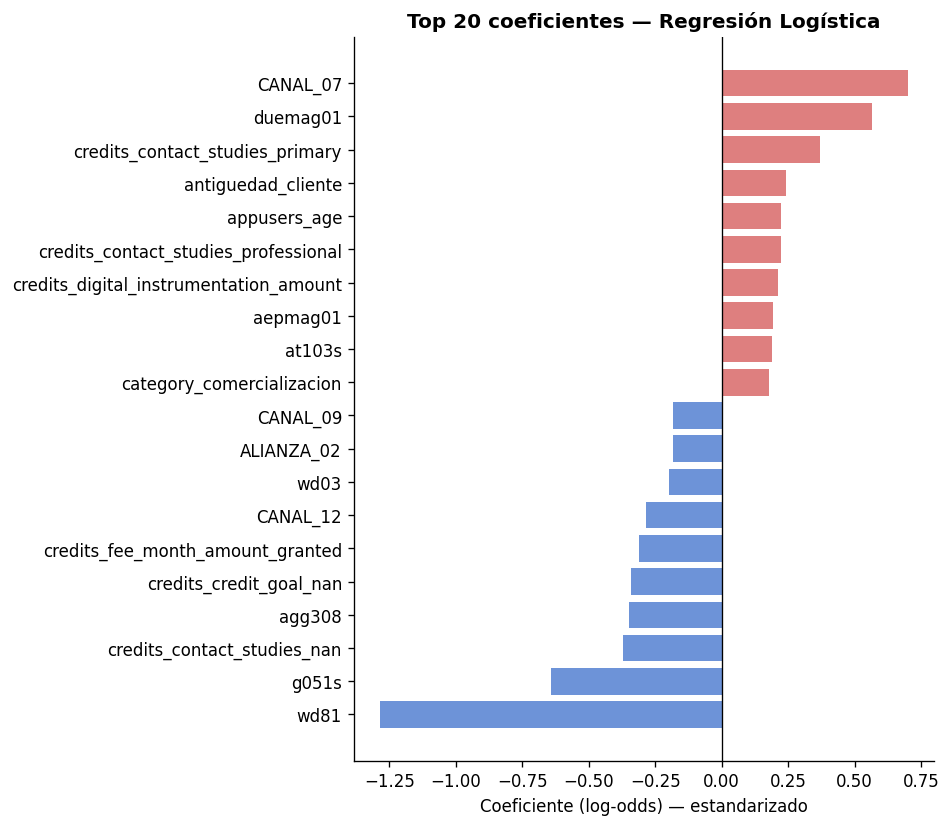

In [7]:
Image(filename=str(BASE / "figures" / "16_coefs_logreg.png"))

**Lectura.** El AUC de test (≈0.70) queda por debajo de XGBoost (≈0.82) y su gap train→test
es mayor: el modelo lineal sobreajusta más en relación a su capacidad frente a 94 variables.
Confirma la ventaja estructural de los árboles en datos tabulares (Grinsztajn et al., 2022).

> La figura de coeficientes la genera `train_logreg()` al correr el script; acá entrenamos
> con los mismos pasos para mostrar el proceso.